In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import json

# 1. Configurações Visuais
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# 2. Carregamento dos Metadados (Dicionário)
try:
    with open('/home/bruno/UESC/DataSUS/DadosTUB/src/dicionario_sinan_tuberculose.json', 'r', encoding='utf-8') as f:
        dicionario = json.load(f)
    print("✅ Dicionário de metadados carregado.")
except FileNotFoundError:
    print("⚠️ Dicionário não encontrado. Prosseguindo apenas com os dados.")

# 3. Carregamento do Dataset Processado
# Forçamos a conversão de datas já no read_csv para ganhar tempo
df = pd.read_csv('/home/bruno/UESC/DataSUS/DadosTUB/data/processed/tuberculose_ilheus_itabuna_limpo_2014_2024.csv')

# Garantindo que colunas de data sejam datetime
colunas_data = [col for col in df.columns if 'Data' in col]
for col in colunas_data:
    df[col] = pd.to_datetime(df[col], errors='coerce')

print(f"✅ Dataset carregado: {df.shape[0]} registros e {df.shape[1]} colunas.")
df.head()

✅ Dicionário de metadados carregado.
✅ Dataset carregado: 3431 registros e 74 colunas.


,Tipo_Notificacao,Agravo_Codigo,Data_Notificacao,Ano_Notificacao,UF_Notificacao,Municipio_Notificacao,Regional_Notificacao,Data_Diagnostico,Ano_Nascimento,Idade_Codigo,...,Beneficiario_Programa_Governo,Agravo_Drogas_Ilicitas,Agravo_Tabagismo,Teste_Rapido_Molecular,Teste_Sensibilidade,Uso_Antiretroviral,Baciloscopia_Apos_6_Meses,Transferencia_Confirmada,UF_Transferencia,Municipio_Transferencia
0,2,A169,1970-01-01 00:00:00.020151204,2015,29,291360,1385,1970-01-01 00:00:00.020151203,1958.0,4057,...,1.0,2.0,2.0,5.0,7.0,0.0,0.0,0.0,NaN,NaN
1,2,A169,1970-01-01 00:00:00.020151204,2015,29,291360,1385,1970-01-01 00:00:00.020151204,1945.0,4070,...,2.0,2.0,2.0,5.0,5.0,0.0,0.0,0.0,NaN,NaN
2,2,A169,1970-01-01 00:00:00.020151223,2015,29,291480,1386,1970-01-01 00:00:00.020151205,1981.0,4034,...,2.0,2.0,1.0,5.0,0.0,0.0,0.0,0.0,NaN,NaN
3,2,A169,1970-01-01 00:00:00.020151207,2015,29,291360,1385,1970-01-01 00:00:00.020151207,1961.0,4054,...,9.0,1.0,1.0,5.0,5.0,0.0,0.0,0.0,NaN,NaN
4,2,A169,1970-01-01 00:00:00.020151207,2015,29,291360,1385,1970-01-01 00:00:00.020151207,1985.0,4030,...,9.0,1.0,2.0,5.0,0.0,0.0,0.0,0.0,NaN,NaN


In [12]:
import numpy as np

# Verifica se a coluna Idade_Anos sumiu
if 'Idade_Anos' not in df.columns:
    print("⚠️ Coluna 'Idade_Anos' não encontrada. Recriando a partir do código original...")
    
    # A função de decodificação que o SUS usa
    def descodificar_idade(codigo):
        if pd.isna(codigo):
            return np.nan
        
        codigo = str(codigo).strip()
        # Se for menor que 4 dígitos ou formato estranho, retornamos Nulo
        if len(codigo) != 4:
            return np.nan
            
        tipo = codigo[0]
        try:
            valor = int(codigo[1:])
        except ValueError:
            return np.nan
        
        if tipo == '4':   # Anos
            return valor
        elif tipo == '3' or tipo == '2': # Meses ou Dias (consideramos 0 anos)
            return 0
        elif tipo == '5': # Acima de 100 anos
            return valor
        else:
            return np.nan
            
    # Aplica a função se a coluna original existir
    if 'Idade_Codigo' in df.columns:
        df['Idade_Anos'] = df['Idade_Codigo'].apply(descodificar_idade)
        print("✅ Coluna 'Idade_Anos' recriada com sucesso! Você já pode rodar o gráfico.")
    else:
        print("🚨 Erro: O dataframe também não possui a 'Idade_Codigo'.")
        print("Colunas disponíveis no seu dataset atual:", df.columns.tolist())
else:
    print("✅ A coluna 'Idade_Anos' já existe. O erro pode ser outra coisa.")

⚠️ Coluna 'Idade_Anos' não encontrada. Recriando a partir do código original...
✅ Coluna 'Idade_Anos' recriada com sucesso! Você já pode rodar o gráfico.


/tmp/ipykernel_10113/3395595207.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([int(abs(x)) for x in ticks])
/tmp/ipykernel_10113/3395595207.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


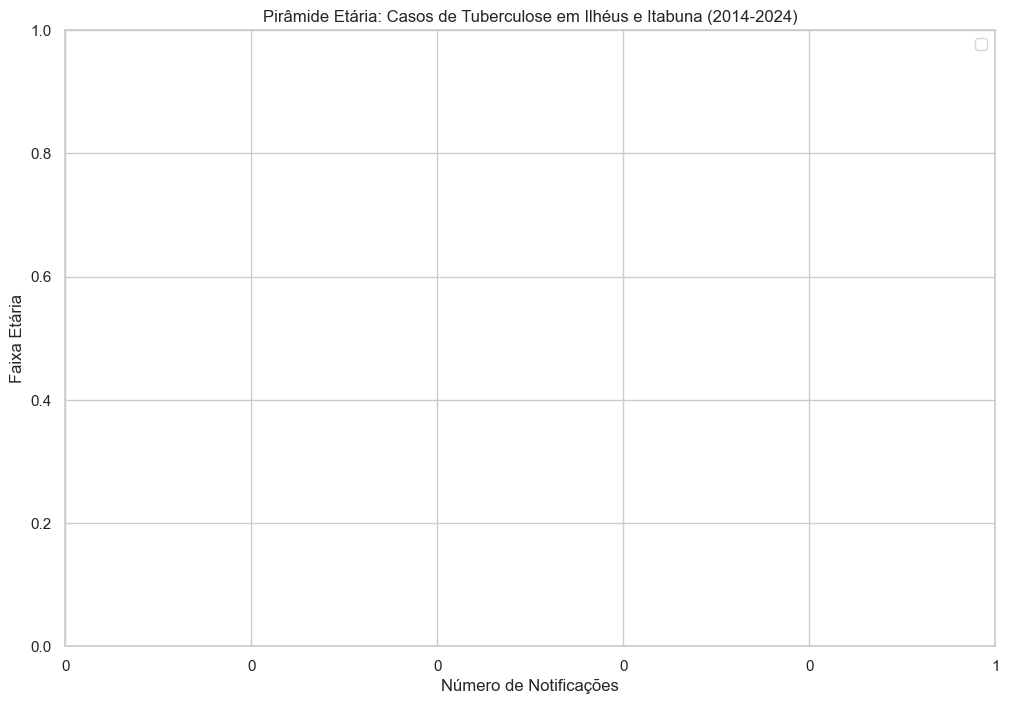

In [13]:
# 1. Criando as Faixas Etárias de 5 em 5 anos
bins = list(range(0, 85, 5)) + [120]
labels = [f'{i}-{i+4}' for i in range(0, 80, 5)] + ['80+']
df['Faixa_Etaria'] = pd.cut(df['Idade_Anos'], bins=bins, labels=labels, right=False)

# 2. Agrupando os dados
piramide = df.groupby(['Faixa_Etaria', 'Sexo'], observed=False).size().reset_index(name='Casos')

# 3. Preparando o espelhamento (Masculino para a esquerda)
# Multiplicamos por -1 para que as barras cresçam para o lado oposto
piramide.loc[piramide['Sexo'] == 'Masculino', 'Casos'] *= -1

# 4. Plotagem
fig, ax = plt.subplots()

# Criamos as barras para cada sexo
sns.barplot(x='Casos', y='Faixa_Etaria', data=piramide[piramide['Sexo'] == 'Masculino'], 
            color='steelblue', label='Masculino', errorbar=None)
sns.barplot(x='Casos', y='Faixa_Etaria', data=piramide[piramide['Sexo'] == 'Feminino'], 
            color='indianred', label='Feminino', errorbar=None)

# Ajustando o eixo X para mostrar valores absolutos (sem o sinal de menos)
ticks = ax.get_xticks()
ax.set_xticklabels([int(abs(x)) for x in ticks])

plt.title('Pirâmide Etária: Casos de Tuberculose em Ilhéus e Itabuna (2014-2024)')
plt.xlabel('Número de Notificações')
plt.ylabel('Faixa Etária')
plt.legend()
plt.show()